In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import calendar
from scipy.stats import norm

In [2]:
current_dir = os.getcwd()
file_path = os.path.normpath(os.path.join(current_dir, "..", "data", "train.xlsx"))
df = pd.read_excel(file_path)

df_timeseries = (df.melt(id_vars=['PRICES'], var_name='Hour', value_name='Price')
            .assign(Hour=lambda x: x['Hour'].str.extract(r'(\d+)').astype(int) - 1)
            .assign(DateTime=lambda x: pd.to_datetime(x['PRICES']) + pd.to_timedelta(x['Hour'], unit='h'))
            .set_index('DateTime')[['Price']]
            .sort_index())



Text(0.5, 1.0, 'Full Price history train data')

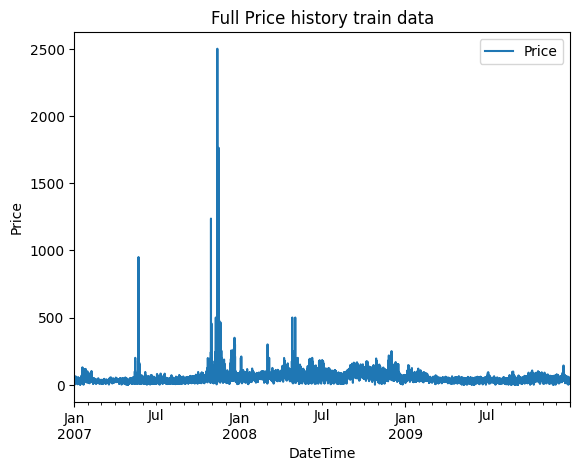

In [3]:
df_timeseries.plot()
plt.ylabel('Price')
plt.title('Full Price history train data')

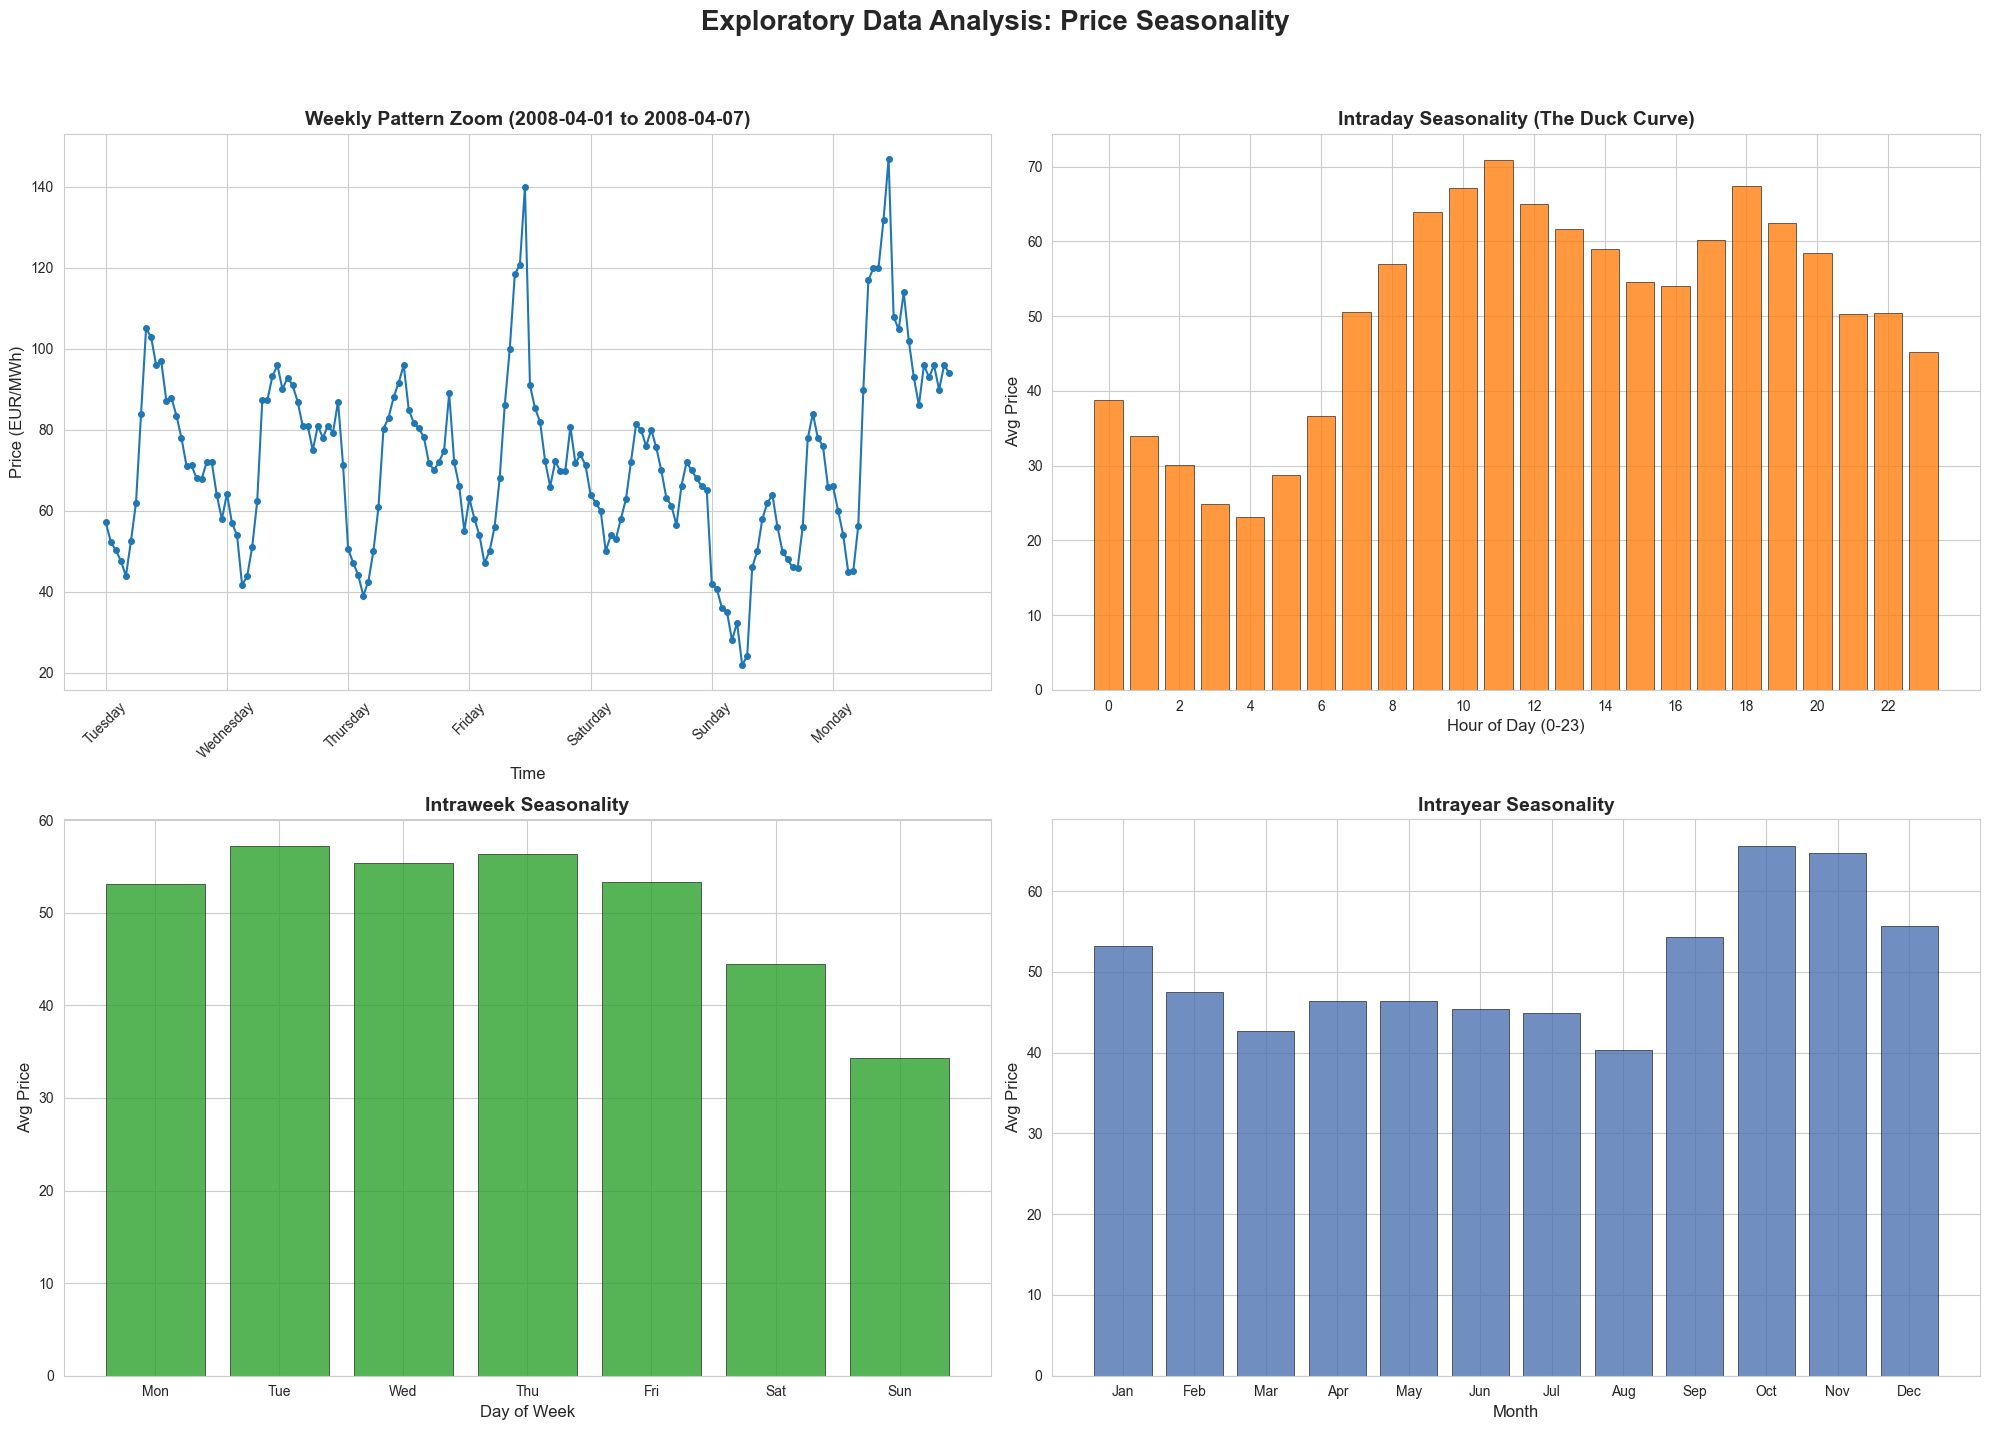

In [4]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

colors = {
    'line': '#1f77b4',    
    'hourly': '#ff7f0e',    
    'daily': '#2ca02c',      
    'monthly': '#4c72b0'     
}

fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Exploratory Data Analysis: Price Seasonality', fontsize=20, weight='bold')

# Weekly Zoom
start_date = '2008-04-01'
end_date = '2008-04-07'
subset = df_timeseries[start_date:end_date]

axes[0,0].plot(subset.index, subset['Price'], 
               color=colors['line'], marker='o', linestyle='-', markersize=4, linewidth=1.5)
axes[0,0].set_xlabel("Time", fontsize=12)
axes[0,0].set_ylabel("Price (EUR/MWh)", fontsize=12)
axes[0,0].set_title(f"Weekly Pattern Zoom ({start_date} to {end_date})", fontsize=14, weight='bold')
axes[0,0].set_xticks(subset.index[::24]) # Tick every 24 hours
axes[0,0].set_xticklabels(subset.index[::24].strftime('%A'), rotation=45)

# Intraday Seasonality
hourly_avg = df_timeseries.groupby(df_timeseries.index.hour)['Price'].mean()
axes[0, 1].bar(hourly_avg.index, hourly_avg.values, color=colors['hourly'], alpha=0.8, edgecolor='black', linewidth=0.5)
axes[0, 1].set_xlabel('Hour of Day (0-23)', fontsize=12)
axes[0, 1].set_ylabel('Avg Price', fontsize=12)
axes[0, 1].set_title('Intraday Seasonality (The Duck Curve)', fontsize=14, weight='bold')
axes[0, 1].set_xticks(range(0, 24, 2)) # Show every second hour to reduce clutter

# Intraweek Seasonality
daily_avg = df_timeseries.groupby(df_timeseries.index.dayofweek)['Price'].mean()
axes[1, 0].bar(daily_avg.index, daily_avg.values, color=colors['daily'], alpha=0.8, edgecolor='black', linewidth=0.5)
axes[1, 0].set_xlabel('Day of Week', fontsize=12)
axes[1, 0].set_ylabel('Avg Price', fontsize=12)
axes[1, 0].set_title('Intraweek Seasonality', fontsize=14, weight='bold')
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

# Intrayear Seasonality
month_avg = df_timeseries.groupby(df_timeseries.index.month)["Price"].mean()
axes[1, 1].bar(month_avg.index, month_avg.values, color=colors['monthly'], alpha=0.8, edgecolor='black', linewidth=0.5)
axes[1, 1].set_xlabel('Month', fontsize=12)
axes[1, 1].set_ylabel('Avg Price', fontsize=12)
axes[1, 1].set_title('Intrayear Seasonality', fontsize=14, weight='bold')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].set_xticklabels([calendar.month_abbr[i] for i in range(1, 13)])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

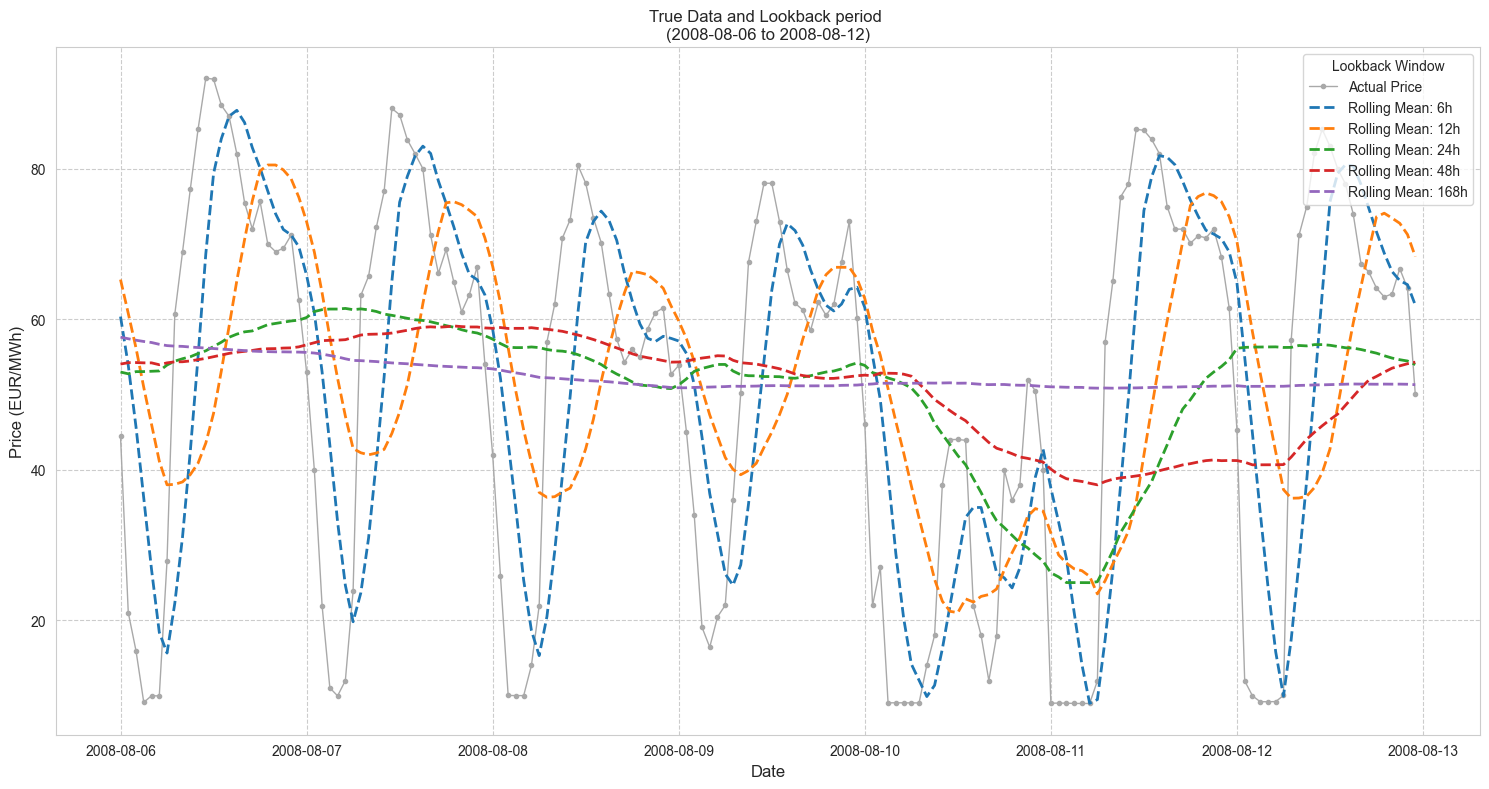

In [5]:
# Lookback periods
start_zoom = '2008-08-06'
end_zoom = '2008-08-12' # 1 week view
subset = df_timeseries[start_zoom:end_zoom]

fig, ax = plt.subplots(figsize=(15, 8))
ax.plot(subset.index, subset['Price'], 
        color='darkgray', marker='o', linestyle='-', markersize=3, linewidth=1, 
        label='Actual Price')

hours_history = [6, 12, 24, 48, 7*24] # 6h to 1 week
indices = np.arange(len(hours_history))
palette = [plt.cm.tab10(i) for i in indices]

for i, h in enumerate(hours_history):
    full_rolling = df_timeseries['Price'].rolling(window=h).mean()
    subset_rolling = full_rolling[start_zoom:end_zoom]

    ax.plot(subset_rolling.index, subset_rolling, 
            color=palette[i], 
            linewidth=2,
            linestyle = '--', 
            label=f'Rolling Mean: {h}h')

ax.set_title(f'True Data and Lookback period \n({start_zoom} to {end_zoom})')
ax.set_ylabel('Price (EUR/MWh)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.legend(loc='upper right', title="Lookback Window", fontsize=10)
ax.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

In [6]:
df_timeseries["rolling_avg"] = df_timeseries.Price.rolling(24).mean()
df_timeseries["rolling_std"] = df_timeseries.Price.rolling(24).std()
df_timeseries['diff'] = df_timeseries.Price - df_timeseries.rolling_avg
df_timeseries['z_score'] = df_timeseries['diff'] / df_timeseries['rolling_std']
df_timeseries.tail(10)

,Price,rolling_avg,rolling_std,diff,z_score
DateTime,,,,,
2009-12-31 14:00:00,33.00,28.127917,12.462038,4.872083,0.390954
2009-12-31 15:00:00,29.82,28.037083,12.440514,1.782917,0.143315
2009-12-31 16:00:00,30.28,27.908333,12.398842,2.371667,0.191281
2009-12-31 17:00:00,40.00,27.700417,12.139063,12.299583,1.013223
2009-12-31 18:00:00,40.48,27.387083,11.680708,13.092917,1.120901
2009-12-31 19:00:00,36.00,27.137083,11.415551,8.862917,0.776390
2009-12-31 20:00:00,29.00,26.928333,11.329892,2.071667,0.182850
2009-12-31 21:00:00,24.82,26.788333,11.334511,-1.968333,-0.173658
2009-12-31 22:00:00,31.28,26.716667,11.298910,4.563333,0.403874


In [7]:
df_timeseries.describe()

,Price,rolling_avg,rolling_std,diff,z_score
count,26304.000000,26281.000000,26281.000000,26281.000000,26281.000000
mean,50.602547,50.627719,18.695916,0.004750,-0.005070
std,40.090049,25.293130,25.700710,32.471710,1.047621
min,0.010000,6.037500,2.044994,-279.743333,-3.341475
25%,29.900000,32.285417,10.128830,-11.190000,-0.775633
50%,43.000000,42.868750,14.392338,0.784583,0.058857
75%,65.000000,66.202917,20.945906,10.129583,0.706689
max,2500.000000,314.269167,498.136117,2333.540417,4.684544


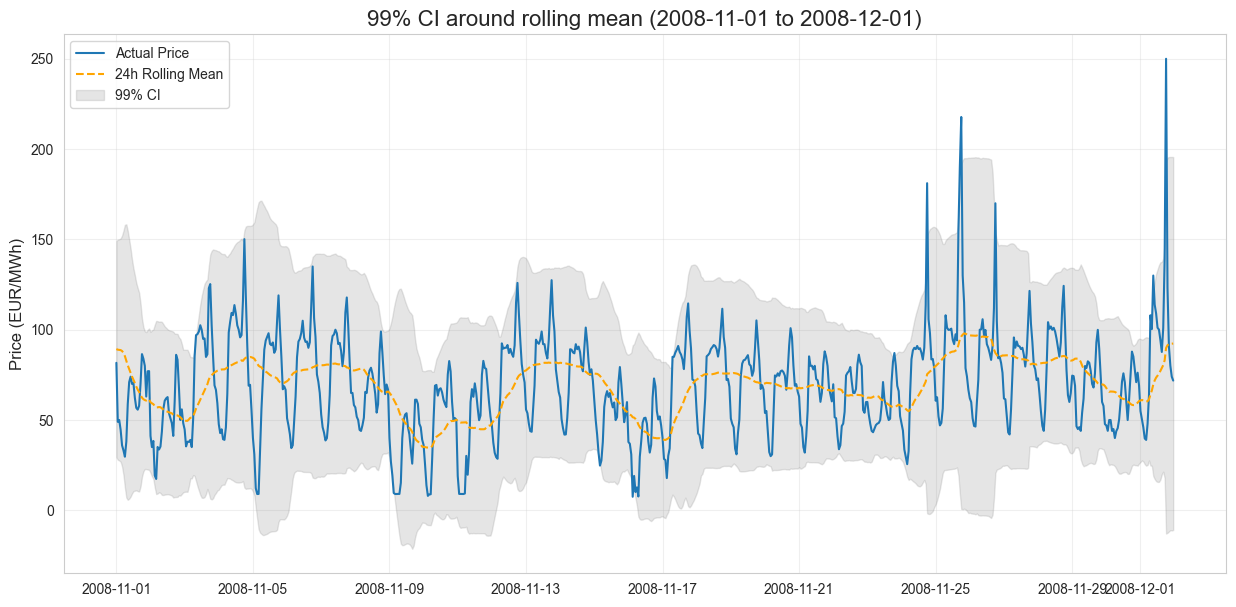

In [8]:
z_bound = norm.ppf(0.99)
df_timeseries["upper_band"] = df_timeseries["rolling_avg"] + (z_bound * df_timeseries["rolling_std"])
df_timeseries["lower_band"] = df_timeseries["rolling_avg"] - (z_bound * df_timeseries["rolling_std"])

start_zoom = '2008-11-01'
end_zoom = '2008-12-01'
subset = df_timeseries[start_zoom:end_zoom]

fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(subset.index, subset['Price'], color='#1f77b4', label='Actual Price', linewidth=1.5)
ax.plot(subset.index, subset['rolling_avg'], color='orange', linestyle='--', label='24h Rolling Mean', linewidth=1.5)
ax.fill_between(subset.index, subset['lower_band'], subset['upper_band'], color='gray', alpha=0.2, label='99% CI')

ax.set_title(f'99% CI around rolling mean ({start_zoom} to {end_zoom})', fontsize=16)
ax.set_ylabel('Price (EUR/MWh)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.show()

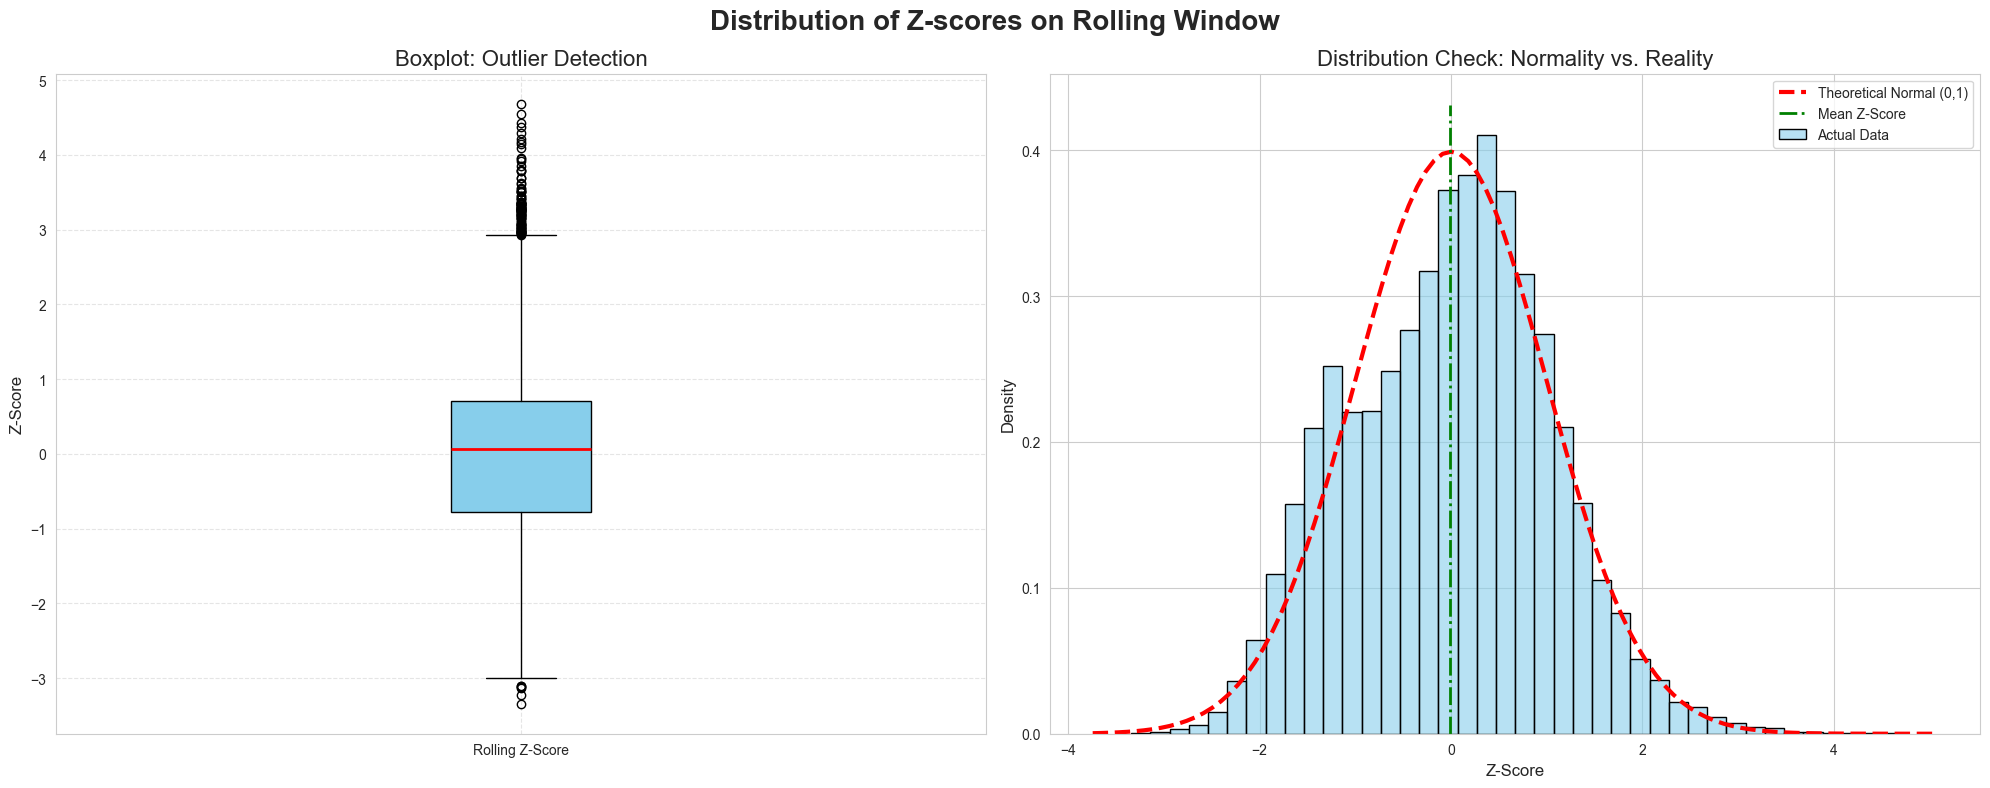

In [9]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Distribution of Z-scores on Rolling Window', fontsize=20, weight='bold')

z_scores_clean = df_timeseries['z_score'].dropna()

axes[0].boxplot(z_scores_clean, vert=True, patch_artist=True,
                boxprops=dict(facecolor="skyblue", color="black"),
                medianprops=dict(color="red", linewidth=2))

axes[0].set_title('Boxplot: Outlier Detection', fontsize=16)
axes[0].set_ylabel('Z-Score', fontsize=12)
axes[0].set_xticklabels(['Rolling Z-Score'])
axes[0].grid(True, linestyle='--', alpha=0.5)


sns.histplot(z_scores_clean, stat="density", bins=40, kde=False, 
             color='skyblue', edgecolor='black', alpha=0.6, ax=axes[1], label='Actual Data')


xmin, xmax = axes[1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, 0, 1) # Standard Normal: Mean=0, Std=1
axes[1].plot(x, p, 'r', linewidth=3, linestyle='--', label='Theoretical Normal (0,1)')
axes[1].set_title('Distribution Check: Normality vs. Reality', fontsize=16)
axes[1].set_xlabel('Z-Score', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)

axes[1].vlines(x=z_scores_clean.mean(), ymin=0, ymax=axes[1].get_ylim()[1], 
               color='green', linestyle='-.', linewidth=2, label='Mean Z-Score')

axes[1].legend()

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Distribution of probabilities 2*P(Z < a) - 1')

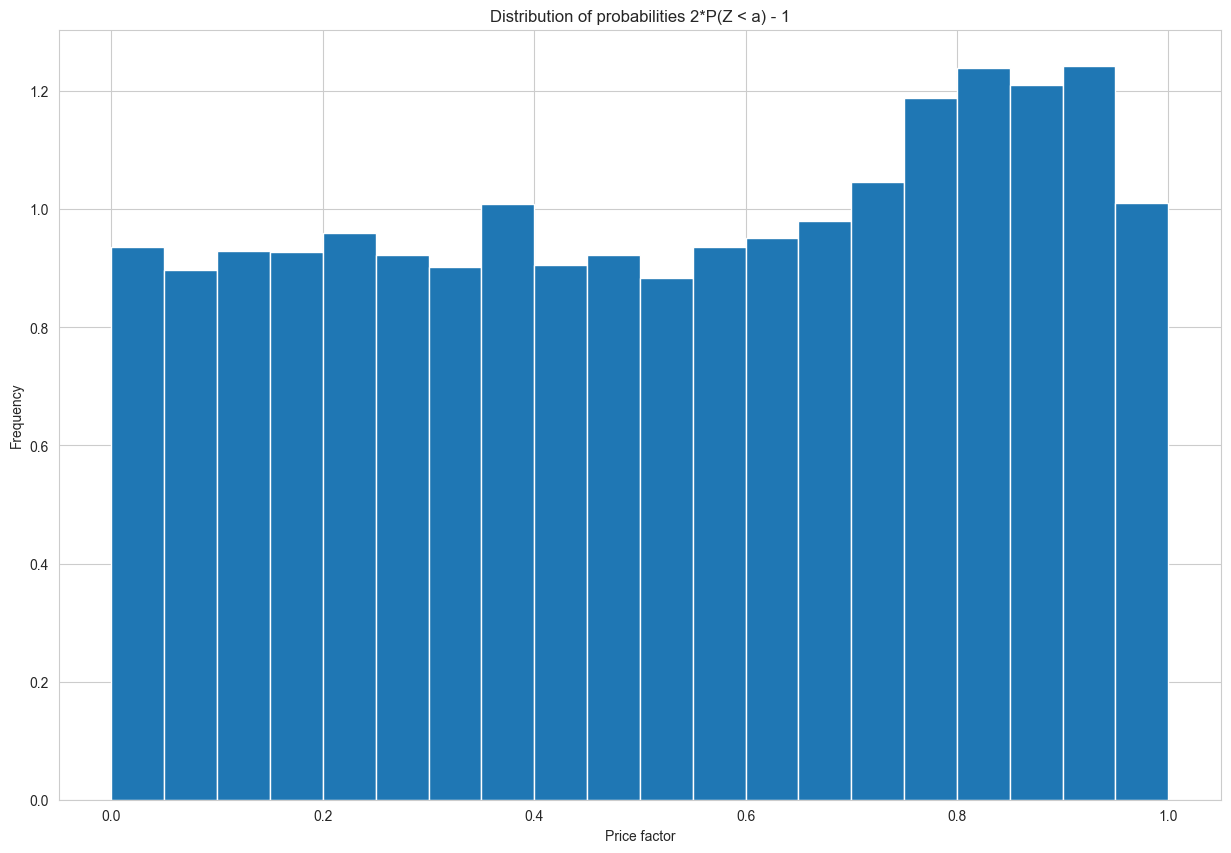

In [12]:
price_factors =  2 * norm.cdf(abs(df_timeseries.z_score)) - 1
plt.hist(price_factors, bins = 20, density=True)
plt.xlabel("Price factor")
plt.ylabel("Frequency")
plt.title("Distribution of probabilities 2*P(Z < a) - 1")